In [1]:
import pandas as pd

train_df = pd.read_csv("../datasets/stroke_train.csv")
test_df = pd.read_csv("../datasets/stroke_test.csv")

print("Training data:", train_df.shape)
print("Test data:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training data: (1137, 12)
Test data: (932, 11)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,47472,Female,58,0,0,Yes,Private,Urban,107.26,38.6,formerly smoked
1,36841,Male,78,1,0,Yes,Self-employed,Rural,56.11,25.5,formerly smoked
2,3135,Female,73,0,0,No,Self-employed,Rural,69.35,NaN,never smoked
3,65218,Male,2,0,0,No,children,Rural,109.10,20.0,Unknown
4,1847,Female,20,0,0,No,Govt_job,Rural,79.53,NaN,never smoked


In [2]:
print("Training data information:")
train_df.info()

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nTarget distribution:")
print(train_df["stroke"].value_counts())

print("\nTarget percentage:")
print(train_df["stroke"].value_counts(normalize=True) * 100)

Training data information:
<class 'pandas.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   str    
 2   age                1137 non-null   str    
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   str    
 6   work_type          1137 non-null   str    
 7   Residence_type     1137 non-null   str    
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   str    
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), str(6)
memory usage: 106.7 KB

Missing values:
id                    0
gender                0
age                   0
hypertension          0
heart_disease         0
ever_mar

In [3]:
print("Unique values in categorical columns:\n")

for column in train_df.select_dtypes(include="object").columns:
    print(f"{column}:")
    print(train_df[column].unique())
    print()


Unique values in categorical columns:

gender:
<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

age:
<StringArray>
[ '31',  '13',  '18',  '65',   '4',  '28',  '64',  '62',  '26',  '63',  '50',
  '77',   '1',  '52',  '24',  '48',  '45',  '74',   '3',  '17',  '54',  '55',
  '67',  '35',  '38',  '81',  '34',  '44',  '79',  '56',  '70',  '30',  '39',
  '29',  '80',  '59',  '51',  '19',  '43',  '71',   '0',  '23',  '53',  '78',
  '66',  '60',  '76',  '22',   '6',  '47',   '2',  '46',  '11',  '33',  '37',
  '49',  '61',  '75',  '40',   '8',  '57',  '12',  '21',  '41',  '58',  '27',
  '20',  '68',  '42',   '5',  '69',   '9',  '36',  '25',  '82',  '73',  '32',
   '7',  '16',  '14',  '72',  '15',  '10', '*82']
Length: 84, dtype: str

ever_married:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

work_type:
<StringArray>
['Govt_job', 'children', 'Private', 'Self-employed', 'Never_worked']
Length: 5, dtype: str

Residence_type:
<StringArray>
['Rural', 'Urban']
Length: 2, dtype: 

C:\Users\chanchal\AppData\Local\Temp\ipykernel_15420\3426786765.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in train_df.select_dtypes(include="object").columns:


In [4]:
# Clean the age column

train_df["age"] = train_df["age"].str.replace("*", "", regex=False)
train_df["age"] = pd.to_numeric(train_df["age"])

print(train_df["age"].dtype)
print(train_df["age"].unique())

int64
[31 13 18 65  4 28 64 62 26 63 50 77  1 52 24 48 45 74  3 17 54 55 67 35
 38 81 34 44 79 56 70 30 39 29 80 59 51 19 43 71  0 23 53 78 66 60 76 22
  6 47  2 46 11 33 37 49 61 75 40  8 57 12 21 41 58 27 20 68 42  5 69  9
 36 25 82 73 32  7 16 14 72 15 10]


In [6]:
# Clean age in test data
test_df["age"] = pd.to_numeric(
    test_df["age"].astype(str).str.replace("*", "", regex=False)
)

print("Test age dtype:", test_df["age"].dtype)

Test age dtype: int64


In [7]:
print("Train age dtype:", train_df["age"].dtype)
print("Test age dtype:", test_df["age"].dtype)

print("\nTrain age missing:", train_df["age"].isnull().sum())
print("Test age missing:", test_df["age"].isnull().sum())

Train age dtype: int64
Test age dtype: int64

Train age missing: 0
Test age missing: 0


In [8]:
print("Missing BMI values")
print("Train:", train_df["bmi"].isnull().sum())
print("Test :", test_df["bmi"].isnull().sum())

print("\nBMI statistics - training data")
print(train_df["bmi"].describe())

Missing BMI values
Train: 52
Test : 57

BMI statistics - training data
count    1085.000000
mean       29.198065
std         7.669615
min        11.300000
25%        24.100000
50%        28.500000
75%        33.200000
max        64.400000
Name: bmi, dtype: float64


In [9]:
# Check numerical columns

print("Numerical columns:")
print(train_df[[
    "age",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi",
    "stroke"
]].describe())

Numerical columns:
               age  hypertension  heart_disease  avg_glucose_level  \
count  1137.000000   1137.000000    1137.000000        1137.000000   
mean     45.189094      0.118734       0.068602         107.664002   
std      23.070207      0.323617       0.252887          47.618723   
min       0.000000      0.000000       0.000000          55.270000   
25%      28.000000      0.000000       0.000000          77.600000   
50%      48.000000      0.000000       0.000000          91.820000   
75%      63.000000      0.000000       0.000000         113.850000   
max      82.000000      1.000000       1.000000         266.590000   

               bmi       stroke  
count  1085.000000  1137.000000  
mean     29.198065     0.120493  
std       7.669615     0.325680  
min      11.300000     0.000000  
25%      24.100000     0.000000  
50%      28.500000     0.000000  
75%      33.200000     0.000000  
max      64.400000     1.000000  


In [10]:
# Check categorical columns

categorical_columns = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(train_df[column].value_counts(dropna=False))


gender:
gender
Female    642
Male      494
Other       1
Name: count, dtype: int64

ever_married:
ever_married
Yes    769
No     368
Name: count, dtype: int64

work_type:
work_type
Private          672
Self-employed    174
children         147
Govt_job         142
Never_worked       2
Name: count, dtype: int64

Residence_type:
Residence_type
Urban    587
Rural    550
Name: count, dtype: int64

smoking_status:
smoking_status
never smoked       416
Unknown            352
formerly smoked    205
smokes             164
Name: count, dtype: int64


In [11]:
# Separate input features (X) and target (y)

X = train_df.drop(columns=["stroke", "id"])
y = train_df["stroke"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (1137, 10)
y shape: (1137,)

Features:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

Target:
stroke


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (909, 10)
X_valid: (228, 10)
y_train: (909,)
y_valid: (228,)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical features
numerical_features = [
    "age",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi"
]

# Categorical features
categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [14]:
X_train_processed = preprocessor.fit_transform(X_train)

X_valid_processed = preprocessor.transform(X_valid)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal validation shape:", X_valid.shape)
print("Processed validation shape:", X_valid_processed.shape)

Original training shape: (909, 10)
Processed training shape: (909, 21)

Original validation shape: (228, 10)
Processed validation shape: (228, 21)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

stroke_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

print("Stroke model pipeline created successfully.")

Stroke model pipeline created successfully.


In [16]:
stroke_model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [17]:
# Make predictions on validation data

y_pred = stroke_model.predict(X_valid)
y_prob = stroke_model.predict_proba(X_valid)[:, 1]

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 stroke probabilities:")
print(y_prob[:10])

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 stroke probabilities:
[0.00296757 0.00082284 0.09428898 0.00134665 0.08496813 0.02558447
 0.14222617 0.35097311 0.00687164 0.08952984]


In [18]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_valid, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_valid, y_pred))

Accuracy: 0.8596491228070176

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       201
           1       0.33      0.19      0.24        27

    accuracy                           0.86       228
   macro avg       0.62      0.57      0.58       228
weighted avg       0.83      0.86      0.84       228



In [19]:
from sklearn.ensemble import RandomForestClassifier

stroke_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

print("Random Forest model pipeline created successfully.")

Random Forest model pipeline created successfully.


In [20]:
stroke_rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [21]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_rf = stroke_rf.predict(X_valid)
y_prob_rf = stroke_rf.predict_proba(X_valid)[:, 1]

accuracy_rf = accuracy_score(y_valid, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_valid, y_pred_rf))

Random Forest Accuracy: 0.8508771929824561

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       201
           1       0.11      0.04      0.06        27

    accuracy                           0.85       228
   macro avg       0.50      0.50      0.49       228
weighted avg       0.79      0.85      0.82       228



In [22]:
stroke_lr_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

print("Balanced Logistic Regression pipeline created successfully.")

Balanced Logistic Regression pipeline created successfully.


In [23]:
stroke_lr_balanced.fit(X_train, y_train)

print("Balanced Logistic Regression model trained successfully.")

Balanced Logistic Regression model trained successfully.


In [24]:
y_pred_balanced = stroke_lr_balanced.predict(X_valid)
y_prob_balanced = stroke_lr_balanced.predict_proba(X_valid)[:, 1]

accuracy_balanced = accuracy_score(y_valid, y_pred_balanced)

print("Balanced Logistic Regression Accuracy:", accuracy_balanced)

print("\nBalanced Logistic Regression Classification Report:")
print(classification_report(y_valid, y_pred_balanced))

Balanced Logistic Regression Accuracy: 0.7543859649122807

Balanced Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.74      0.84       201
           1       0.31      0.89      0.46        27

    accuracy                           0.75       228
   macro avg       0.65      0.81      0.65       228
weighted avg       0.90      0.75      0.80       228



In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

print("Threshold comparison:\n")

for threshold in thresholds:
    y_pred_threshold = (y_prob_balanced >= threshold).astype(int)

    precision = precision_score(y_valid, y_pred_threshold, zero_division=0)
    recall = recall_score(y_valid, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_valid, y_pred_threshold, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold comparison:

Threshold: 0.20 | Precision: 0.23 | Recall: 1.00 | F1: 0.37
Threshold: 0.30 | Precision: 0.25 | Recall: 1.00 | F1: 0.41
Threshold: 0.40 | Precision: 0.27 | Recall: 0.96 | F1: 0.43
Threshold: 0.50 | Precision: 0.31 | Recall: 0.89 | F1: 0.46
Threshold: 0.60 | Precision: 0.34 | Recall: 0.74 | F1: 0.47
Threshold: 0.70 | Precision: 0.35 | Recall: 0.67 | F1: 0.46
Threshold: 0.80 | Precision: 0.37 | Recall: 0.48 | F1: 0.42


In [26]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    stroke_lr_balanced,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("5-Fold Cross-Validation Results:\n")

print("Accuracy:", cv_results["test_accuracy"].mean())
print("Precision:", cv_results["test_precision"].mean())
print("Recall:", cv_results["test_recall"].mean())
print("F1:", cv_results["test_f1"].mean())

5-Fold Cross-Validation Results:

Accuracy: 0.7502279928897132
Precision: 0.302550174933844
Recall: 0.8103174603174603
F1: 0.4402070136308686


Confusion Matrix:
[[148  53]
 [  3  24]]


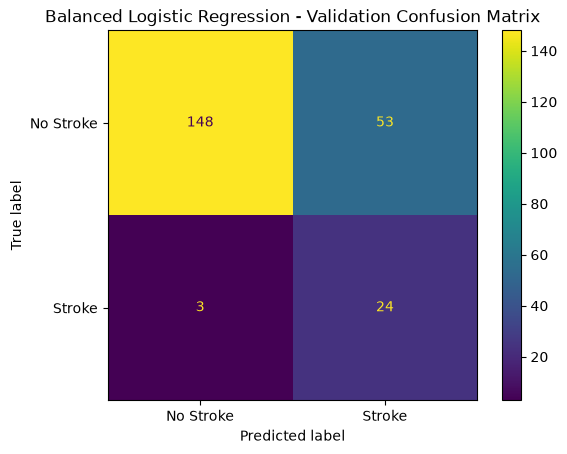

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_pred_balanced)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Stroke", "Stroke"]
)

disp.plot()
plt.title("Balanced Logistic Regression - Validation Confusion Matrix")
plt.show()

In [28]:
# Train the final model on the complete training dataset

stroke_final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

stroke_final_model.fit(X, y)

print("Final stroke model trained successfully.")

Final stroke model trained successfully.


In [29]:
import joblib

joblib.dump(
    stroke_final_model,
    "../models/stroke_model.pkl"
)

print("Final stroke model saved successfully.")

Final stroke model saved successfully.


In [30]:
import joblib

loaded_stroke_model = joblib.load("../models/stroke_model.pkl")

print("Saved stroke model loaded successfully.")
print(type(loaded_stroke_model))

Saved stroke model loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [31]:
test_patient = pd.DataFrame([{
    "gender": "Male",
    "age": 65,
    "hypertension": 1,
    "heart_disease": 1,
    "ever_married": "Yes",
    "work_type": "Private",
    "Residence_type": "Urban",
    "avg_glucose_level": 180.0,
    "bmi": 30.0,
    "smoking_status": "formerly smoked"
}])

prediction = loaded_stroke_model.predict(test_patient)[0]
probability = loaded_stroke_model.predict_proba(test_patient)[0, 1]

print("Prediction:", prediction)
print("Stroke probability:", probability)

Prediction: 1
Stroke probability: 0.8225755128287758
